In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [57]:
# Apply the default theme
sns.set_theme()

In [58]:
#data_url = "https://raw.githubusercontent.com/dthonon/pna_loup_suivi/main/data/"
data_url = "/home/daniel/Code/pna_loup_suivi/data/"
# Lecture des départements
dept = pd.read_csv(
    data_url + "departements-region.csv",
    sep=";",
    header=0,
    names=[
        "Num_Département",
        "Département",
        "Région",
    ],
)
# Lecture des dommages aux animaux de rente
dommages = pd.read_csv(data_url + "dommages.csv", sep=";", 
                       dtype={"Année": int})
# Ajout des départements et régions
dommages = pd.merge(dommages, dept, on="Département")
# dommages.head()

In [59]:
region_summary = (
    dommages
    .groupby(['Année', 'Région'], as_index=False)[['Nb_dossiers', 'Nb_animaux_tués', "Nb_dossiers_N1", "Nb_animaux_tués_N1", "Nb_dossiers_N2", "Nb_animaux_tués_N2"]]
    .sum()
)
region_summary.sort_values(['Année', 'Région'], inplace=True)
region_summary[region_summary['Année'] == 2020 ]

,Année,Région,Nb_dossiers,Nb_animaux_tués,Nb_dossiers_N1,Nb_animaux_tués_N1,Nb_dossiers_N2,Nb_animaux_tués_N2
44,2020,Auvergne-Rhône-Alpes,1173.0,3980.0,1015.0,3623.0,852.0,2902.0
45,2020,Bourgogne-Franche-Comté,104.0,425.0,38.0,107.0,8.0,35.0
46,2020,Centre-Val de Loire,0.0,0.0,0.0,0.0,0.0,0.0
47,2020,Grand Est,132.0,253.0,212.0,476.0,128.0,431.0
48,2020,Hauts-de-France,2.0,2.0,0.0,0.0,0.0,0.0
49,2020,Normandie,41.0,62.0,0.0,0.0,0.0,0.0
50,2020,Nouvelle-Aquitaine,23.0,78.0,15.0,71.0,22.0,152.0
51,2020,Occitanie,92.0,383.0,77.0,246.0,157.0,460.0
52,2020,Pays de la Loire,0.0,0.0,0.0,0.0,0.0,0.0
53,2020,Provence-Alpes-Côte d'Azur,2163.0,6666.0,2288.0,7535.0,1921.0,6692.0


In [60]:
dommages[(dommages['Année'] == 2020) & (dommages['Région'] == "Nouvelle-Aquitaine")].sort_values("Département")

,Année,Département,Nb_dossiers,Nb_animaux_tués,Nb_dossiers_N1,Nb_animaux_tués_N1,Nb_dossiers_N2,Nb_animaux_tués_N2,Num_Département,Région
272,2020,Charente-Maritime,0.0,0.0,NaN,NaN,NaN,NaN,17,Nouvelle-Aquitaine
273,2020,Corrèze,NaN,NaN,NaN,NaN,NaN,NaN,19,Nouvelle-Aquitaine
275,2020,Creuse,NaN,NaN,NaN,NaN,NaN,NaN,23,Nouvelle-Aquitaine
286,2020,Haute-Vienne,NaN,NaN,NaN,NaN,NaN,NaN,87,Nouvelle-Aquitaine
301,2020,Pyrénées-Atlantiques,23.0,78.0,15.0,71.0,22.0,152.0,64,Nouvelle-Aquitaine


In [61]:
france_total = (
    dommages[dommages['Année'] < 2025]
    .groupby("Année")
    .agg(
        Nb_dossiers=('Nb_dossiers', 'sum'),
        Nb_animaux_tués=('Nb_animaux_tués', 'sum'),
        Nb_dossiers_N1=('Nb_dossiers_N1', 'sum'),
        Nb_animaux_tués_N1=('Nb_animaux_tués_N1', 'sum'),
        Nb_dossiers_N2=('Nb_dossiers_N2', 'sum'),
        Nb_animaux_tués_N2=('Nb_animaux_tués_N2', 'sum')
    )
)
france_total

,Nb_dossiers,Nb_animaux_tués,Nb_dossiers_N1,Nb_animaux_tués_N1,Nb_dossiers_N2,Nb_animaux_tués_N2
Année,,,,,,
2013,1863.0,6209.0,0.0,0.0,0.0,0.0
2014,2305.0,8576.0,0.0,0.0,0.0,0.0
2015,2428.0,8935.0,2305.0,8576.0,1863.0,6209.0
2016,2756.0,9932.0,0.0,0.0,0.0,0.0
2017,3228.0,11993.0,0.0,0.0,0.0,0.0
2018,3088.0,10672.0,0.0,0.0,0.0,0.0
2019,3651.0,12094.0,0.0,0.0,0.0,0.0
2020,3730.0,11849.0,3645.0,12058.0,3088.0,10672.0
2021,3537.0,10826.0,0.0,0.0,0.0,0.0


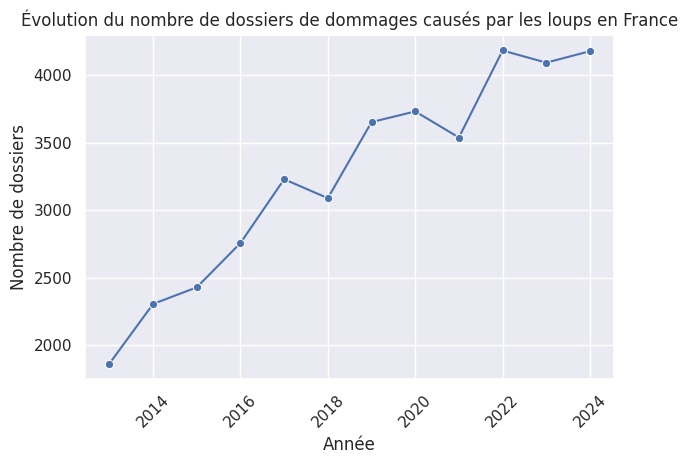

In [62]:
diagramme = sns.lineplot(data=france_total, x="Année", y="Nb_dossiers", marker="o")
diagramme.set_title("Évolution du nombre de dossiers de dommages causés par les loups en France")
diagramme.set_xlabel("Année")
diagramme.set_ylabel("Nombre de dossiers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

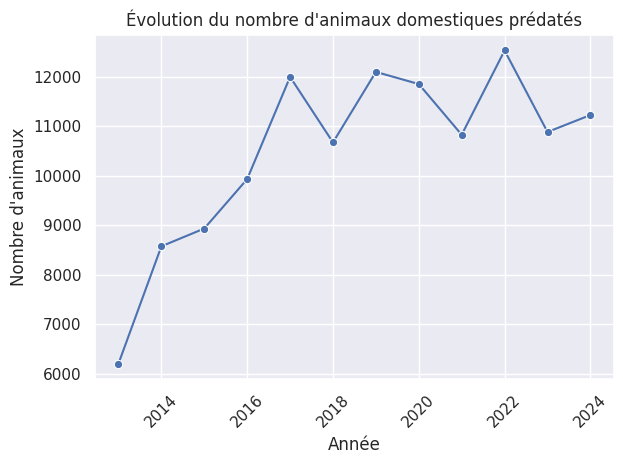

In [63]:
diagramme = sns.lineplot(data=france_total, x="Année", y="Nb_animaux_tués", marker="o")
diagramme.set_title("Évolution du nombre d'animaux domestiques prédatés")
diagramme.set_xlabel("Année")
diagramme.set_ylabel("Nombre d'animaux")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

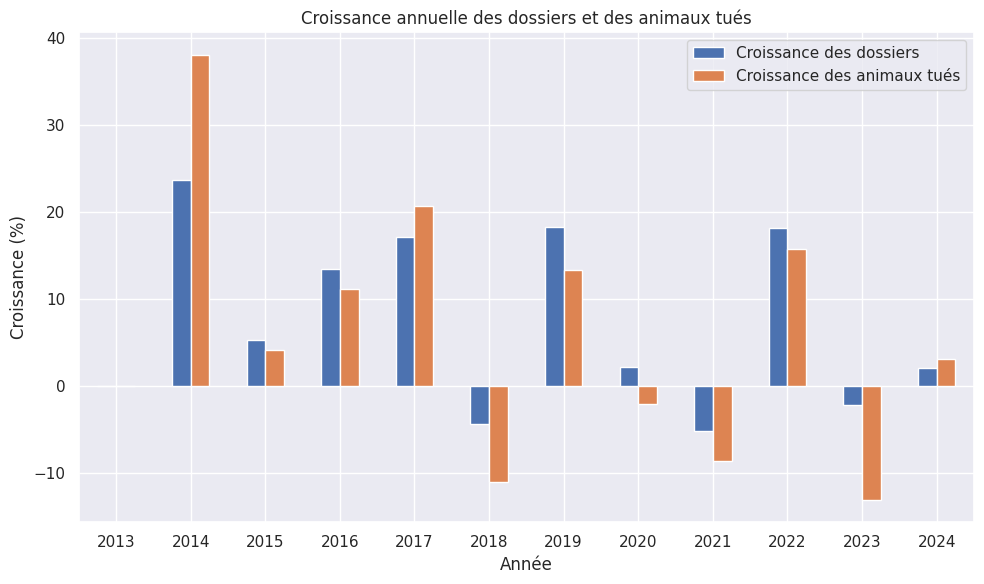

In [64]:
france_total['Nb_dossiers_croissance'] = france_total['Nb_dossiers'].pct_change() * 100
france_total['Nb_animaux_tués_croissance'] = france_total['Nb_animaux_tués'].pct_change() * 100
france_total.plot(y=['Nb_dossiers_croissance', 'Nb_animaux_tués_croissance'], kind='bar', figsize=(10, 6))
plt.title("Croissance annuelle des dossiers et des animaux tués")
plt.ylabel("Croissance (%)")
plt.xlabel("Année")
plt.xticks(rotation=0)
plt.legend(["Croissance des dossiers", "Croissance des animaux tués"])
plt.tight_layout()
plt.show()

In [65]:
ecarts = france_total[['Nb_dossiers', 'Nb_animaux_tués']]
ecarts_N1 = france_total[['Nb_dossiers_N1', 'Nb_animaux_tués_N1']]
ecarts_N2 = france_total[['Nb_dossiers_N2', 'Nb_animaux_tués_N2']]
ecarts_N1.index = ecarts_N1.index - 1
ecarts_N2.index = ecarts_N2.index - 2
ecarts = pd.merge(ecarts, ecarts_N1, on="Année", how="left", suffixes=("", "_N1"))
ecarts = pd.merge(ecarts, ecarts_N2, on="Année", how="left", suffixes=("", "_N2"))
ecarts

,Nb_dossiers,Nb_animaux_tués,Nb_dossiers_N1,Nb_animaux_tués_N1,Nb_dossiers_N2,Nb_animaux_tués_N2
Année,,,,,,
2013,1863.0,6209.0,0.0,0.0,1863.0,6209.0
2014,2305.0,8576.0,2305.0,8576.0,0.0,0.0
2015,2428.0,8935.0,0.0,0.0,0.0,0.0
2016,2756.0,9932.0,0.0,0.0,0.0,0.0
2017,3228.0,11993.0,0.0,0.0,0.0,0.0
2018,3088.0,10672.0,0.0,0.0,3088.0,10672.0
2019,3651.0,12094.0,3645.0,12058.0,0.0,0.0
2020,3730.0,11849.0,0.0,0.0,3508.0,11146.0
2021,3537.0,10826.0,3513.0,10509.0,3495.0,10545.0


In [66]:
ecarts['%_écart_dossiers_N1'] = np.where(
    ecarts['Nb_dossiers_N1'] != 0,
    (ecarts['Nb_dossiers_N1'] - ecarts['Nb_dossiers']) / ecarts['Nb_dossiers_N1'] * 100,
    np.nan
)
ecarts['%_écart_dossiers_N2'] = np.where(
    ecarts['Nb_dossiers_N2'] != 0,
    (ecarts['Nb_dossiers_N2'] - ecarts['Nb_dossiers']) / ecarts['Nb_dossiers_N2'] * 100,
    np.nan
)
ecarts[['%_écart_dossiers_N1', '%_écart_dossiers_N2']]

,%_écart_dossiers_N1,%_écart_dossiers_N2
Année,,
2013,NaN,0.000000
2014,0.000000,NaN
2015,NaN,NaN
2016,NaN,NaN
2017,NaN,NaN
2018,NaN,0.000000
2019,-0.164609,NaN
2020,NaN,-6.328392
2021,-0.683177,-1.201717


In [67]:
ecarts['%_écart_animaux_tués_N1'] = np.where(
    ecarts['Nb_animaux_tués_N1'] != 0,
    (ecarts['Nb_animaux_tués_N1'] - ecarts['Nb_animaux_tués']) / ecarts['Nb_animaux_tués_N1'] * 100,
    np.nan
)
ecarts['%_écart_animaux_tués_N2'] = np.where(
    ecarts['Nb_animaux_tués_N2'] != 0,
    (ecarts['Nb_animaux_tués_N2'] - ecarts['Nb_animaux_tués']) / ecarts['Nb_animaux_tués_N2'] * 100,
    np.nan
)
ecarts[['%_écart_animaux_tués_N1', '%_écart_animaux_tués_N2']]

,%_écart_animaux_tués_N1,%_écart_animaux_tués_N2
Année,,
2013,NaN,0.000000
2014,0.000000,NaN
2015,NaN,NaN
2016,NaN,NaN
2017,NaN,NaN
2018,NaN,0.000000
2019,-0.298557,NaN
2020,NaN,-6.307195
2021,-3.016462,-2.664770
